# Basic synthesis by batch

# Imports

In [3]:
import os
import sys

chemin_stl_dev = os.path.join(os.getcwd(), 'STL_21')

sys.path.append(chemin_stl_dev)

In [4]:
import scipy.stats as stats

In [5]:
from astropy import units as u
from astropy.cosmology import Planck15

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.fft
import healpy as hp
from importlib import reload
from functools import partial
import sys
import healpy as hp
from clean_utils import * 

In [7]:
torch.cuda.is_available()

True

In [8]:
patch = np.load("/rds/rds-clecat/generative_modelling/patches/patch_lon0.0_lat0.0_npix256_reso2.34arcmin.npy")

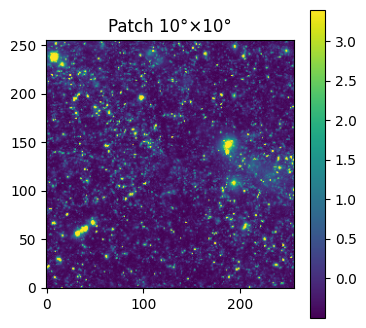

In [9]:
vmin, vmax = np.percentile(patch, [1, 99])

plt.figure(figsize=(4, 4))
im = plt.imshow(patch, vmin=vmin, vmax=vmax, origin='lower')
plt.colorbar(im)
plt.title("Patch 10°×10°")
plt.show()
#regarder d'autres patchs 

In [10]:
patch = (patch - np.mean(patch))/np.std(patch) 

# nbatch = 1

In [11]:
import sys

sys.path.append('/rds/rds-clecat/generative_modelling/STL_21')

#from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch as DataClass
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch as DataClass
from STL_main.ST_Operator import ST_Operator as SO
from STL_main.Synthesis import optimize_scattering_LBFGS

In [12]:
target = np.load("/rds/rds-clecat/generative_modelling/patches/patch_lon0.0_lat0.0_npix256_reso2.34arcmin.npy")
seed=1

In [13]:
target = DataClass(target, pbc=False)
st_op = target.get_ST_op()

compute_cross_matrix = None

In [14]:
u1, histo1 = optimize_scattering_LBFGS(
        target=target,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=1,
        max_iter=500,
        lr=0.01,
        history_size=50,
        print_iter=10,
        verbose=True,
        seed=seed,
    )

Running synthesis on device cuda:0 dtype torch.float64
Initial shape for u: (1, 1, 256, 256)
Warning! Data with shape (8, 8) too small to be cropped with border 4. Using border=3 instead.
Synthesis on 3968 ST coefficients
[LBFGS] inner iter 10, loss = 7.015386e+01
[LBFGS] inner iter 20, loss = 4.700616e+01
[LBFGS] inner iter 30, loss = 2.062356e+01
[LBFGS] inner iter 40, loss = 7.520268e+00
[LBFGS] inner iter 50, loss = 3.801819e+00
[LBFGS] inner iter 60, loss = 2.233806e+00
[LBFGS] inner iter 70, loss = 1.647850e+00
[LBFGS] inner iter 80, loss = 1.422095e+00
[LBFGS] inner iter 90, loss = 1.216755e+00
[LBFGS] inner iter 100, loss = 1.094917e+00
[LBFGS] inner iter 110, loss = 1.009697e+00
[LBFGS] inner iter 120, loss = 9.491290e-01
[LBFGS] inner iter 130, loss = 9.269452e-01
[LBFGS] inner iter 140, loss = 8.984437e-01
[LBFGS] inner iter 150, loss = 8.601549e-01
[LBFGS] inner iter 160, loss = 8.088255e-01
[LBFGS] inner iter 170, loss = 7.848448e-01
[LBFGS] inner iter 180, loss = 7.594777

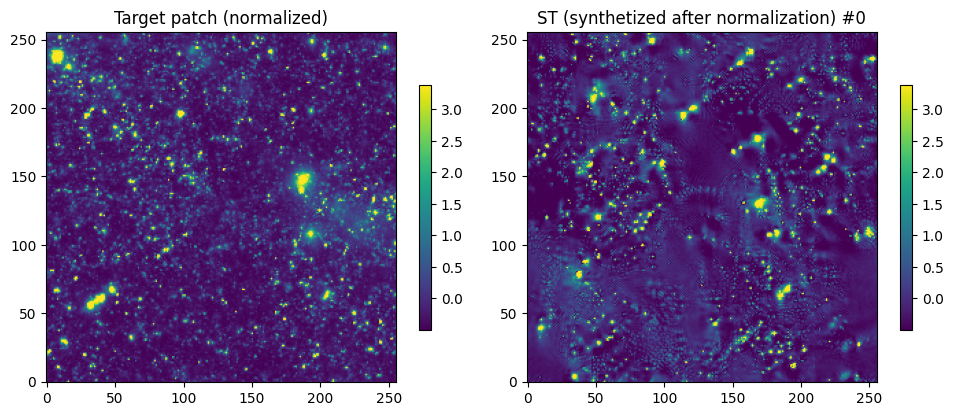

-0.0037605715523308272
0.9953130530252511
1.0


In [16]:
plt.figure(figsize=(10,4))
vmin, vmax = np.nanpercentile(patch, [1, 99])

plt.subplot(1,2,1)
#plt.imshow(np.fft.fftshift(patch), origin="lower", vmin=vmin, vmax=vmax)
plt.imshow(patch, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("Target patch (normalized)")

plt.subplot(1,2,2)
plt.imshow(u1.cpu().numpy(), origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("ST (synthetized after normalization) #0")

plt.tight_layout()
plt.show()

print(np.mean(u1.cpu().numpy()))
print(np.std(u1.cpu().numpy()))
print(np.std(patch))

In [17]:
u_np = u1.detach().cpu().numpy()

paths = save_patch(
    patch=u_np,
    name_of_the_patch="synth_patch",
    out_dir="/rds/rds-clecat/generative_modelling/nbatch=1",
    overwrite=True,
)

print(f"Saved {len(paths)} synthesized patches")

Saved 1 synthesized patches


# # nbatch = 10

In [18]:
target = np.load("/rds/rds-clecat/generative_modelling/patches/patch_lon0.0_lat0.0_npix256_reso2.34arcmin.npy")
seed=1

In [19]:
target = DataClass(target, pbc=False)
st_op = target.get_ST_op()

compute_cross_matrix = None

In [20]:
u1, histo1 = optimize_scattering_LBFGS(
        target=target,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=10,
        max_iter=500,
        lr=0.01,
        history_size=30,
        print_iter=10,
        verbose=True,
        seed=seed,
    )

Running synthesis on device cuda:0 dtype torch.float64
Initial shape for u: (10, 1, 256, 256)
Warning! Data with shape (8, 8) too small to be cropped with border 4. Using border=3 instead.
Synthesis on 3968 ST coefficients
[LBFGS] inner iter 10, loss = 7.182112e+01
[LBFGS] inner iter 20, loss = 5.365103e+01
[LBFGS] inner iter 30, loss = 3.136976e+01
[LBFGS] inner iter 40, loss = 1.487725e+01
[LBFGS] inner iter 50, loss = 8.575831e+00
[LBFGS] inner iter 60, loss = 4.905456e+00
[LBFGS] inner iter 70, loss = 2.541592e+00
[LBFGS] inner iter 80, loss = 1.635156e+00
[LBFGS] inner iter 90, loss = 1.332267e+00
[LBFGS] inner iter 100, loss = 1.088182e+00
[LBFGS] inner iter 110, loss = 9.372129e-01
[LBFGS] inner iter 120, loss = 8.251914e-01
[LBFGS] inner iter 130, loss = 7.563357e-01
[LBFGS] inner iter 140, loss = 7.196760e-01
[LBFGS] inner iter 150, loss = 6.928967e-01
[LBFGS] inner iter 160, loss = 6.755272e-01
[LBFGS] inner iter 170, loss = 6.605411e-01
[LBFGS] inner iter 180, loss = 6.44956

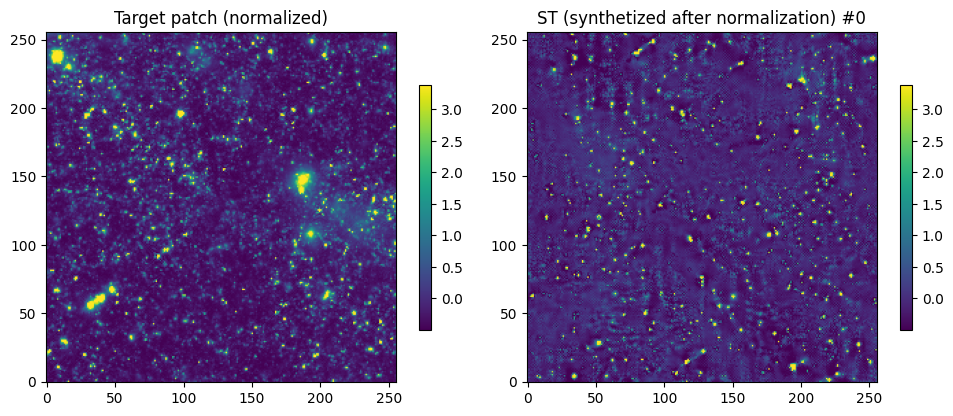

0.0001999948779809287
1.0014347181961487
1.0


In [21]:
plt.figure(figsize=(10,4))
vmin, vmax = np.nanpercentile(patch, [1, 99])

plt.subplot(1,2,1)
#plt.imshow(np.fft.fftshift(patch), origin="lower", vmin=vmin, vmax=vmax)
plt.imshow(patch, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("Target patch (normalized)")

plt.subplot(1,2,2)
plt.imshow(u1[0].cpu().numpy(), origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("ST (synthetized after normalization) #0")

plt.tight_layout()
plt.show()

print(np.mean(u1.cpu().numpy()))
print(np.std(u1.cpu().numpy()))
print(np.std(patch))

In [22]:
u_np = u1.detach().cpu().numpy()

paths = save_patch(
    patch=u_np,
    name_of_the_patch="synth_patch",
    out_dir="/rds/rds-clecat/generative_modelling/nbatch=10",
    overwrite=True,
)

print(f"Saved {len(paths)} synthesized patches")


Saved 10 synthesized patches


# Comparison

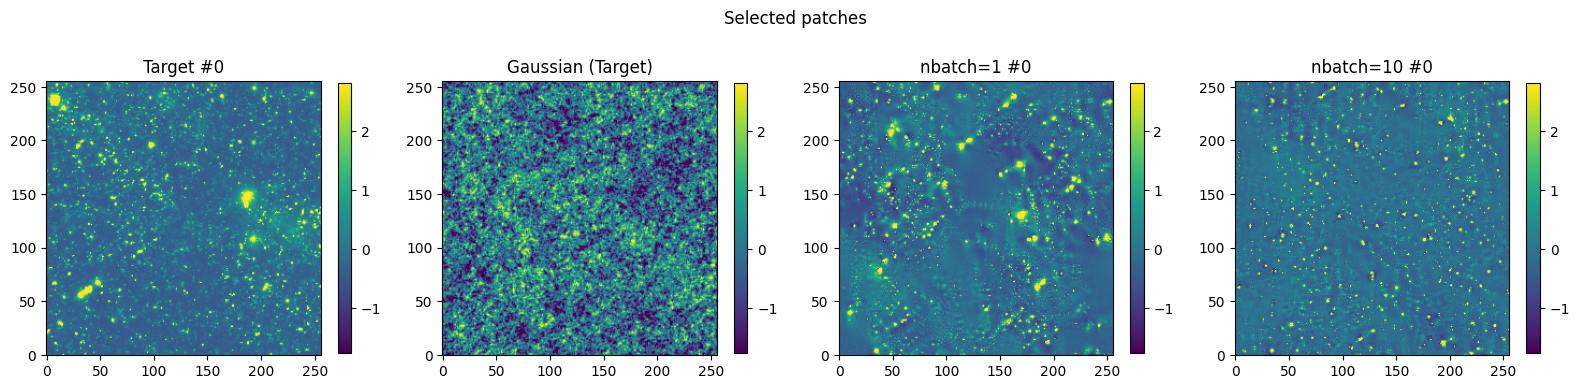

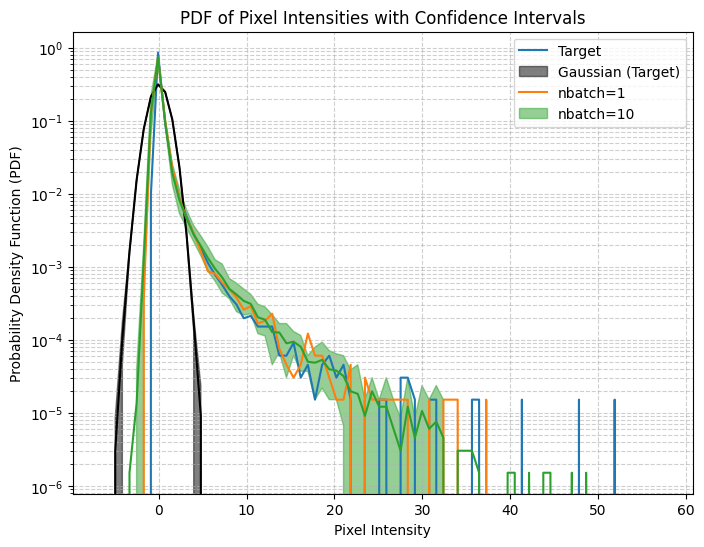

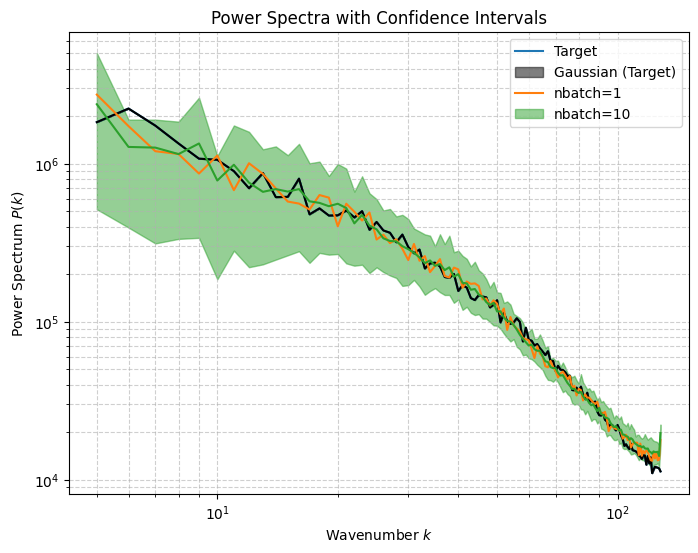

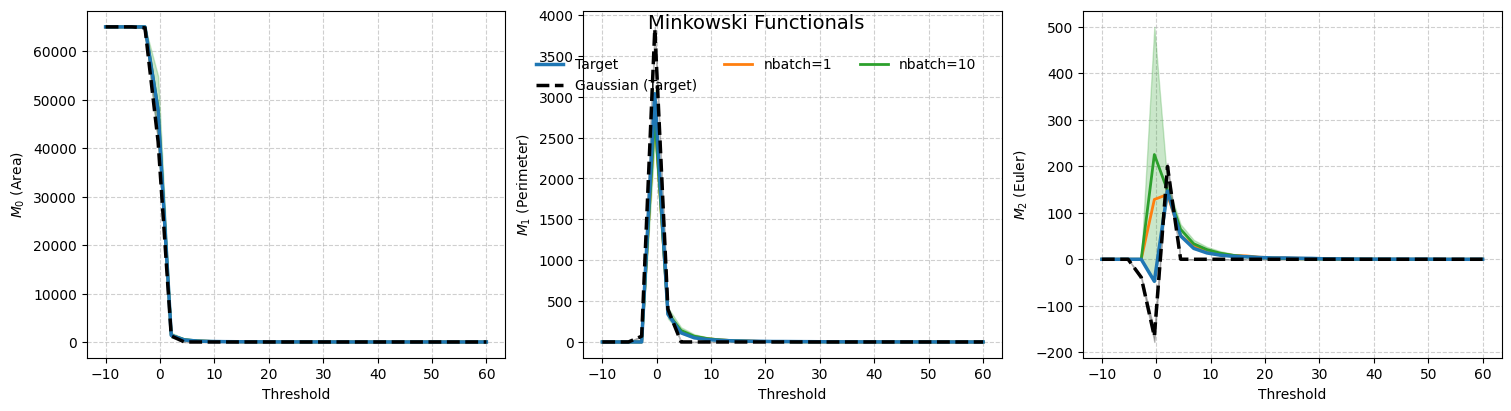

In [28]:
from clean_utils import *

res = flexible_analysis(
    folders=["/rds/rds-clecat/generative_modelling/patches/patch_lon0.0_lat0.0_npix256_reso2.34arcmin.npy","/rds/rds-clecat/generative_modelling/nbatch=1" , "/rds/rds-clecat/generative_modelling/nbatch=10"],
    labels=["Target", "nbatch=1", "nbatch=10"],
    colors=["tab:blue","tab:orange","tab:green"],
    ps_kmin=5,
    ps_kmax=350,
    gaussian=True,
    gaussian_n=10,
    gaussian_from="target",
    imshow_indices=[0, 0, 0],   # montre le patch #0 des trois dossiers
    pdf_bins=80,
    pdf_range=(-7, 58),
    mf_min_threshold=-10,
    mf_max_threshold=60,
)
